In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

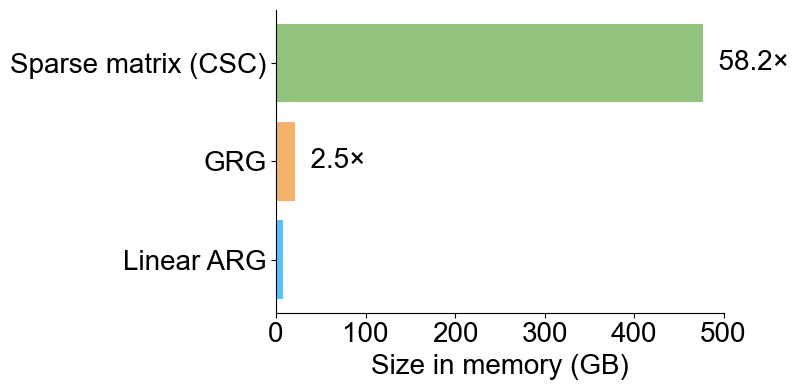

In [2]:
linarg_stats = pd.read_csv('../../data/ukb20279_linarg_stats.tsv', sep='\t')
size_in_memory = pd.read_csv('../../data/ukb20279_grg_xsi_scipy_size_benchmark.tsv', sep='\t')

sim = {
    'linarg': np.sum(linarg_stats[(linarg_stats.linarg=='ukb20279_chr1-22') & (linarg_stats.chrom.isin([1, 11, 21]))].size_in_memory),
    'grg': np.sum(size_in_memory.grg_size_in_memory),
    'scipy': np.sum(size_in_memory.scipy_size_in_memory),
}

methods = [
    'scipy',
    'grg',
    'linarg',
]

name = {
    'grg': 'GRG',
    'linarg': 'Linear ARG',
    'scipy': 'Sparse matrix (CSC)'
    
}

plt.rcParams['font.family'] = 'Arial'
y = np.arange(len(methods))
colors = ['#93c47d', '#f6b26b', '#56C1FF']

fig, ax = plt.subplots(figsize=(8, 4))
for i, method in enumerate(methods):
    ax.barh(y[i], sim[method], color=colors[i], label='Size in memory (GB)' if i == 0 else "")
ax.set_yticks(y)
ax.set_yticklabels([name[m] for m in methods], fontsize=20)
ax.invert_yaxis()
ax.set_xlabel('Size in memory (GB)', fontsize=20)
for i, method in enumerate(methods):
    if method == 'linarg':
        continue
    speedup = sim[method] / sim['linarg']
    ax.text(sim[method] + 0.05, y[i], f"  {speedup:.1f}×", va='center', fontsize=20)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.tick_params(labelsize=20)
plt.tight_layout()
plt.xlim(0, 500)
plt.show()

In [3]:
sim

{'linarg': np.float64(8.209250912000002),
 'grg': np.float64(20.60156928),
 'scipy': np.float64(477.47026426900004)}

In [4]:
scipy_common = pd.read_csv('../../data/scipy_size_benchmark_common.tsv', sep='\t')
scipy_common

,chr,method,size_in_memory_gb
0,1,scipy,254.071072
1,11,scipy,164.419232
2,21,scipy,46.204324


In [5]:
linarg_all_size = np.sum(linarg_stats[(linarg_stats.linarg=='ukb20279_chr1-22') & (linarg_stats.chrom.isin([1, 11, 21]))].size_in_memory)
linarg_common_size = np.sum(linarg_stats[(linarg_stats.linarg=='ukb20279_maf_0.01_chr1-22') & (linarg_stats.chrom.isin([1, 11, 21]))].size_in_memory)
scipy_all_size = np.sum(size_in_memory.scipy_size_in_memory)
scipy_common_size = np.sum(scipy_common.size_in_memory_gb)

linarg_all_size, linarg_common_size, scipy_all_size, scipy_common_size

(np.float64(8.209250912000002),
 np.float64(4.220488083),
 np.float64(477.47026426900004),
 np.float64(464.69462718))

In [6]:
scipy_all_size / linarg_all_size, scipy_common_size / linarg_common_size

(np.float64(58.16246444252914), np.float64(110.10447560597933))

In [7]:
(scipy_all_size - scipy_common_size) / (linarg_all_size - linarg_common_size)

np.float64(3.2029071761589156)